In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.svm import SVR
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import *
from random import *
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression
from datetime import datetime
%matplotlib inline

seed(888)

# 1 Load data from feather

In [130]:
# load feather data and convert to dataframe
# general data
general_data = pd.read_feather("/mnt/Data/main_reduced.ftr", columns=None, use_threads=True, storage_options=None)
general_data = pd.DataFrame(general_data)
# mri data
brain_data = pd.read_feather("/mnt/Data/fs_derivatives_reduced.ftr", columns=None, use_threads=True, storage_options=None)
brain_data = pd.DataFrame(brain_data)

# 2 Compute Age at MRI scan

In [131]:
general_data['Age'] = pd.DatetimeIndex(pd.to_datetime(general_data.iloc[:,9912], format='%Y-%m-%d %H:%M:%S')).year - general_data.iloc[:,23]
brain_data["Age"] = general_data["Age"]

# 3 Exclusions

## Age

In [132]:
# delete rows that have a missing value for Age
index_age = general_data[np.isnan(general_data["Age"])].index
brain_data = brain_data.drop(index_age)
general_data = general_data.drop(index_age)
print(len(index_age), "people were excluded based on missing age")

16 people were excluded based on missing age


## Disorders

In [133]:
# only these exclusions
# exclude people with disorders of the nervous system
nervous = general_data[general_data["diagnoses_icd10_f41270_0_0"].str.contains("G")==True].index
brain_data = brain_data.drop(nervous)
general_data = general_data.drop(nervous)
print("People excluded due to disorders of the nervous system (G):", len(nervous))

# exclude people with malicious neoplasm in the brain
neoplasm = general_data[general_data["diagnoses_icd10_f41270_0_0"].str.contains("C71")==True].index
brain_data = brain_data.drop(neoplasm)
general_data = general_data.drop(neoplasm)
print("People excluded due to malicious neoplasms in the brain (C71):", len(neoplasm))

# exclude people with circulatory disease 
circulatory = general_data[general_data["diagnoses_icd10_f41270_0_0"].str.contains("I")==True].index
brain_data = brain_data.drop(circulatory)
general_data = general_data.drop(circulatory)
print("People excluded due to circulatory disease (I):", len(circulatory))

print("Total number of exclusions due to disorders:", len(nervous)+len(neoplasm)+len(circulatory))


People excluded due to disorders of the nervous system (G): 1336
People excluded due to malicious neoplasms in the brain (C71): 14
People excluded due to circulatory disease (I): 3188
Total number of exclusions due to disorders: 4538


## Missing brain values

In [134]:
nan_all = brain_data[brain_data.iloc[:,1:2544:2].isnull().any(axis=1)].index
general_data = general_data.drop(nan_all)
brain_data = brain_data.drop(nan_all)
print("Number of people with missing brain values:", len(nan_all))


Number of people with missing brain values: 95


# 4 Hand grip preprocessing

In [135]:
general_data["HG"] = np.nan
general_data["HGL"] = general_data.iloc[:,64]
general_data["HGR"] = general_data.iloc[:,68]

right = general_data[general_data.iloc[:,814] == "Right-handed"].index
left = general_data[general_data.iloc[:,814] == "Left-handed"].index
both = general_data[general_data.iloc[:,814] == "Use both right and left hands equally"].index

general_data.loc[right,"HG"] = general_data.loc[right,"HGR"]
general_data.loc[left,"HG"] = general_data.loc[left,"HGL"]
both_value = general_data[["HGR", "HGL"]].max(axis=1)
general_data.loc[both,"HG"] = both_value[both]

# 5 Self-report preprocessing

# 6 Split data based on completion of accelerometer assessment

In [136]:
# split data into people with completed physical activity accelerometer assessment (PA_yes) and without (PA_no)
comp = "Completed"
main_test = general_data[general_data["invitation_to_physical_activity_study_acceptance_f110005_0_0"] == comp]
main_train = general_data[general_data["invitation_to_physical_activity_study_acceptance_f110005_0_0"] != comp]
brain_test = brain_data[general_data["invitation_to_physical_activity_study_acceptance_f110005_0_0"] == comp]
brain_train = brain_data[general_data["invitation_to_physical_activity_study_acceptance_f110005_0_0"] != comp]

print(main_test.shape[0], "participants completed the accelerometer assessment and are assigned to the test set.")
print(main_train.shape[0], "participants did not complete the accelerometer assessment are assigned the training set.")


17076 participants completed the accelerometer assessment and are assigned to the test set.
21442 participants did not complete the accelerometer assessment are assigned the training set.


# 7 Physical activity preprocessing

/tmp/ipykernel_1402247/3575678275.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_test["Wear time in minutes"] = main_test.iloc[:,16686]*1440


People excluded due to wear time < 8000 minutes: 2094
Yes    14982
No         0
Name: data_quality_good_wear_time_f90015_0_0, dtype: int64
Yes    14982
No         0
Name: data_quality_good_calibration_f90016_0_0, dtype: int64


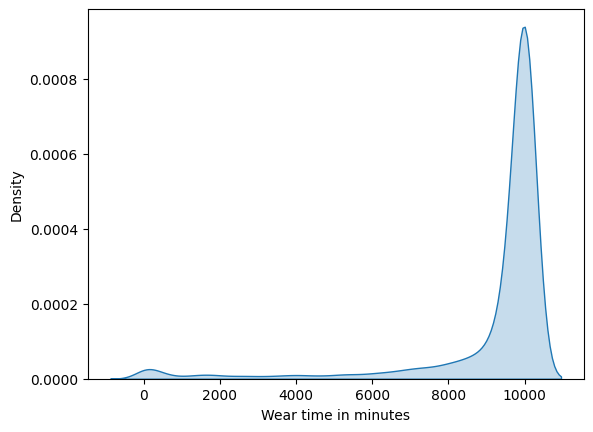

In [137]:
# get weartime duration in minutes (it's in days at default)
main_test["Wear time in minutes"] = main_test.iloc[:,16686]*1440
sns.kdeplot(data = main_test, x= 'Wear time in minutes', fill=True)

# exclude people with insufficient weartime weartime < 8000 minutes
wear_time_test = main_test[main_test["Wear time in minutes"]<8000].index
print("People excluded due to wear time < 8000 minutes:", len(wear_time_test))
brain_test = brain_test.drop(wear_time_test)
main_test = main_test.drop(wear_time_test)

# check wear time and data quality
print(main_test.iloc[:,16650].value_counts())
print(main_test.iloc[:,16651].value_counts())

In [138]:
# distributions are cumulative -> substract ditributions from each other
# determine fraction of weartime spent doing light PA (between 30 and 125 milligravites)
light_PA = np.asarray(main_test.iloc[:,16763]-main_test.iloc[:,16748])
# get it in minutes / week
light_PA = light_PA * main_test["Wear time in minutes"]
main_test["Light PA"] = light_PA

# determine fraction of weartime spent doing moderate PA (between 125 and 400 milligravites)
moderate_PA = np.asarray(main_test.iloc[:,16774]-main_test.iloc[:,16763])
moderate_PA = moderate_PA * main_test["Wear time in minutes"]
main_test["Moderate PA"] = moderate_PA

# determine fraction of weartime spent doing vigorous PA (above 400 milligravites)
vigorous_PA = np.asarray(1-main_test.iloc[:,16774])
vigorous_PA = vigorous_PA * main_test["Wear time in minutes"]
main_test["Vigorous PA"] = vigorous_PA

# fraction of weartime for above 30 mg -> total summed light, moderate, and vigorous PA
total_PA = np.asarray(1-main_test.iloc[:,16748])
total_PA = total_PA * main_test["Wear time in minutes"]
main_test["Total PA"] = total_PA

# moderate + 2* vigorous PA -> weighten greater than moderate activity
main_test["MVPA"] = main_test["Moderate PA"] + main_test["Vigorous PA"]*2

# 8 Variable selection

In [139]:
# same for full dataset without exclusions
main_test_crop = []
main_test_crop = pd.DataFrame(main_test_crop)

main_test_crop["ID"] = main_test.iloc[:,0]
main_test_crop["Age"] = main_test["Age"]
main_test_crop["Gender"] = main_test.iloc[:,22]
main_test_crop["TPA"] = main_test["Total PA"]
main_test_crop["VPA"] = main_test["Vigorous PA"]
main_test_crop["MPA"] = main_test["Moderate PA"]
main_test_crop["MVPA"] = main_test["MVPA"]
main_test_crop["LPA"] = main_test["Light PA"]
main_test_crop["BMI"] = main_test.iloc[:,11580]
main_test_crop["SRLPA"] = main_test.iloc[:,9989]
main_test_crop["SRMPA"] = main_test.iloc[:,9990]
main_test_crop["SRVPA"] = main_test.iloc[:,9991]
main_test_crop["FI"] = main_test.iloc[:,9052]
main_test_crop["HG"] = main_test["HG"]
main_test_crop["IS"] = main_test['uk_biobank_assessment_centre_f54_2_0']
main_test_crop["SES"] = main_test.iloc[:,456]
main_test_crop["HR"] = main_test.iloc[:,10079]
main_test_crop["JPA"] = main_test.iloc[:,507]
main_test_crop["DBP"] = main_test.iloc[:,1551]
main_test_crop["SBP"] = main_test.iloc[:,1559]

main_test = main_test_crop


# main train
main_train_crop = []
main_train_crop = pd.DataFrame(main_train_crop)

main_train_crop["ID"] = main_train.iloc[:,0]
main_train_crop["Age"] = main_train["Age"]
main_train_crop["Gender"] = main_train.iloc[:,22]
main_train_crop["BMI"] = main_train.iloc[:,11580]
main_train_crop["SRLPA"] = main_train.iloc[:,9989]
main_train_crop["SRMPA"] = main_train.iloc[:,9990]
main_train_crop["SRVPA"] = main_train.iloc[:,9991]
main_train_crop["FI"] = main_train.iloc[:,9052]
main_train_crop["HG"] = main_train["HG"]
main_train_crop["IS"] = main_train['uk_biobank_assessment_centre_f54_2_0']
main_train_crop["SES"] = main_train.iloc[:,456]
main_train_crop["HR"] = main_train.iloc[:,10079]
main_train_crop["JPA"] = main_train.iloc[:,507]
main_train_crop["DBP"] = main_train.iloc[:,1551]
main_train_crop["SBP"] = main_train.iloc[:,1559]

main_train = main_train_crop

# 9 Randomly split test set into exploration (50%) and validation (50%) set

In [140]:
length = int(main_test.shape[0])
half = int(int(main_test.shape[0])/2)
random_indices = sample(range(0, length), half)
main_test_validate = main_test.iloc[random_indices,:]
main_test = main_test.drop(main_test.iloc[random_indices].index)
brain_test_validate = brain_test.iloc[random_indices,:]
brain_test = brain_test.drop(brain_test.iloc[random_indices].index)

# check whether there is any overlap
overlap = np.asarray(main_test_validate["ID"]) == np.asarray(main_test["ID"])
print("Number of overlapping IDs", overlap.sum())

print("Size of exploration set:", main_test.shape[0])
print("Size of validation set:", main_test_validate.shape[0])

Number of overlapping IDs 0
Size of exploration set: 7491
Size of validation set: 7491


# 10 Pickle

In [141]:
# store away validation data
main_test_validate.to_pickle("main_test_validate.pkl")
brain_test_validate.to_pickle("brain_test_validate.pkl")

# pickle exploration data for further analysis in next script
main_test.to_pickle("1_main_test.pkl")
main_train.to_pickle("1_main_train.pkl")
brain_test.to_pickle("1_brain_test.pkl")
brain_train.to_pickle("1_brain_train.pkl")